
## Logistic Regression for Binary Classification: Part-2

## Objective
To implement Logistic Regression for a binary classification problem (Placed / Not Placed)
using Hours_Studied and Previous_Score as input features.


## Step 1: Import Required Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


## Step 2: Load Dataset

In [26]:
# Load the Result dataset from the specified file path into a Pandas DataFrame
df = pd.read_csv("/content/drive/MyDrive/logistic_regression_100_rows.csv")

In [27]:
# Display the first five rows of the DataFrame to quickly inspect the data
df.head()

,Hours_Studied,Previous_Score,Result
0,11,42,1
1,5,50,1
2,12,41,1
3,9,40,1
4,1,36,1


In [28]:
df.head()

,Hours_Studied,Previous_Score,Result
0,11,42,1
1,5,50,1
2,12,41,1
3,9,40,1
4,1,36,1


In [29]:
# Display concise information about the DataFrame such as column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Hours_Studied   100 non-null    int64
 1   Previous_Score  100 non-null    int64
 2   Result          100 non-null    int64
dtypes: int64(3)
memory usage: 2.5 KB


In [30]:
# Check for missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
Hours_Studied,0
Previous_Score,0
Result,0


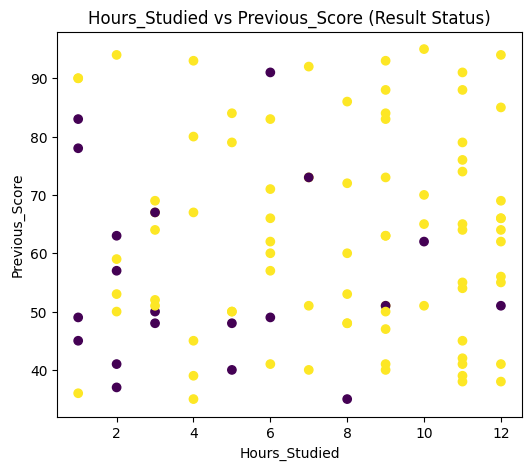

In [31]:
# Create a scatter plot of Hours_Studied vs Previous_Score
# Color points based on Result status (0 = Not Placed, 1 = Placed)

plt.figure(figsize=(6, 5))
plt.scatter(df['Hours_Studied'], df['Previous_Score'], c=df['Result'])
plt.xlabel('Hours_Studied')
plt.ylabel('Previous_Score')
plt.title('Hours_Studied vs Previous_Score (Result Status)')
plt.show()


## Step 4: Feature Selection

In [32]:
# Select the independent variables (features): Hours_Studied and Previous_Score
X = df[['Hours_Studied', 'Previous_Score']]

# Select the dependent variable (target): Result status (1 = Placed, 0 = Not Placed)
y = df['Result']


## Step 5: Train-Test Split

In [33]:
# Split the dataset into training and testing sets
# 80% data is used for training and 20% for testing
# stratify=y ensures both classes are equally represented in train and test sets
# random_state ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 6: Feature Scaling

In [34]:
# Create a StandardScaler object to normalize the feature values
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# This standardizes features to have mean = 0 and standard deviation = 1
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
# (Important: do NOT fit again on test data)
X_test = scaler.transform(X_test)

## Step 7: Model Training

In [35]:
# Create an object of the Logistic Regression model
model = LogisticRegression()


In [36]:
# Train (fit) the model using the training data
# The model learns the relationship between Hours_Studied, Previous_Score and Result outcome
model.fit(X_train, y_train)

LogisticRegression()

## Step 8: Predictions

In [37]:
# Predict the Result outcome for the test dataset using the trained model
y_pred = model.predict(X_test)

## Step 9: Model Evaluation

In [38]:
# Display the accuracy of the model
# Accuracy shows the percentage of correctly classified instances
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


In [39]:
# Display the confusion matrix
# It shows counts of True Positives, True Negatives, False Positives, and False Negatives
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[ 0  4]
 [ 0 16]]


In [40]:
# Display the classification report
# It includes precision, recall, F1-score, and support for each class
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.80      1.00      0.89        16

    accuracy                           0.80        20
   macro avg       0.40      0.50      0.44        20
weighted avg       0.64      0.80      0.71        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 10: ROC Curve

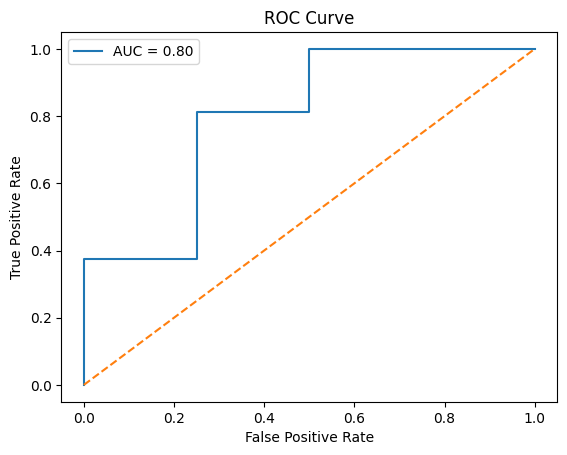

In [41]:
# Predict the probability of the positive class (Placed = 1) for the test data
# [:, 1] selects the probability of class '1'
y_prob = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR) for different thresholds
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label='AUC = %.2f' % roc_auc)

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

# Label the axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot
plt.title('ROC Curve')

# Display legend
plt.legend()

# Show the plot
plt.show()


## Step 11: Prediction for New Data

In [42]:
# Create a new data point for a student with Hours_Studied = 7.8 and Previous_Score = 120
new_student = np.array([[15, 80]])

# Apply the same scaling used for training data
new_student_scaled = scaler.transform(new_student)

# Predict the Result outcome for the new student
prediction = model.predict(new_student_scaled)

# Display the prediction result in a readable format
print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")

Prediction: Pass


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
# Take input values from the user
Hours_Studied = float(input("Enter Hours_Studied: "))
Previous_Score = float(input("Enter Previous_Score: "))

# Create input array in required 2D format
new_student = np.array([[Hours_Studied, Previous_Score]])

# Apply the same scaling used during model training
new_student_scaled = scaler.transform(new_student)

# Predict the Result outcome for the given input
prediction = model.predict(new_student_scaled)

# Display the prediction result in a user-friendly format
print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")

Enter Hours_Studied: 8
Enter Previous_Score: 50
Prediction: Pass


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [44]:
import pickle

In [45]:
pickle.dump(model,open('BCModel.pkl','wb'))

In [46]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load Trained Logistic Regression Model
model = pickle.load(open("BCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read user inputs
    Hours_Studied = float(request.form['Hours_Studied'])
    Previous_Score = float(request.form['Previous_Score'])

    # Prediction
    prediction = model.predict(np.array([[Hours_Studied, Previous_Score]]))

    # Convert numeric prediction to text
    if prediction[0] == 1:
        result = "Student is Pass"
    else:
        result = "Student is Fail"

    return render_template(
        "index.html",
        prediction_text=result
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file as 'index.html'

In [47]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Result Prediction</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{

    background:#eef4ff;
    display:flex;
    justify-content:center;
    align-items:center;
    height:100vh;

}

.container{

    width:430px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 8px 20px rgba(0,0,0,.2);

}

h1{

    text-align:center;
    color:#1565c0;

}

h3{

    text-align:center;
    color:#666;
    margin-top:8px;
    margin-bottom:25px;

}

label{

    display:block;
    font-weight:bold;
    margin-top:15px;
    margin-bottom:6px;

}

input{

    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;

}

button{

    width:100%;
    padding:13px;
    margin-top:25px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;

}

button:hover{

    background:#0d47a1;

}

.result{

    margin-top:25px;
    padding:18px;
    border-radius:8px;
    text-align:center;
    font-size:22px;
    font-weight:bold;
    background:#e8f5e9;
    color:green;

}

footer{

    margin-top:20px;
    text-align:center;
    color:#777;
    font-size:13px;

}

</style>

</head>

<body>

<div class="container">

<h1>Result Prediction System</h1>

<h3>Binary Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Enter Student Hours_Studied</label>

<input
type="number"
name="Hours_Studied"
step="0.01"
min="0"
max="10"
placeholder="Example : 8.25"
required>

<label>Enter Previous_Score Score</label>

<input
type="number"
name="Previous_Score"
placeholder="Example : 120"
required>

<button type="submit">

Predict Result

</button>

</form>

{% if prediction_text %}

<div class="result">

{{ prediction_text }}

</div>

{% endif %}

<footer>

By Dr. Sachin Balawant Takmare

</footer>

</div>

</body>

</html>

SyntaxError: invalid decimal literal (335828912.py, line 26)